# Phân tích Thống kê Mô tả Dữ liệu COVID-19

Notebook này thực hiện phân tích thống kê mô tả trên dữ liệu COVID-19 từ Our World in Data.
Chúng ta sẽ tải dữ liệu từ URL compact, xử lý giá trị thiếu, tính các chỉ số như mean, median, mode, variance, std, max, min, percentile 60, quartiles, IQR.
Ngoài ra, vẽ biểu đồ để quan sát phân bố và boxplot.

## Thư viện cần thiết
- pandas: Xử lý dữ liệu
- numpy: Tính toán số học
- scipy.stats: Thống kê nâng cao
- matplotlib & seaborn: Vẽ biểu đồ

In [1]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

# Thiết lập style cho biểu đồ
plt.style.use('seaborn-v0_8')
sns.set_palette('husl')

## 1. Tải và Khám phá Dữ liệu

Tải file CSV compact từ URL.

In [2]:
# URL của file compact CSV
url = 'https://catalog.ourworldindata.org/garden/covid/latest/compact/compact.csv'

# Tải dữ liệu vào DataFrame
covid_data = pd.read_csv(url)

# Kiểm tra cột có sẵn
print('Cột có sẵn:', covid_data.columns.tolist())
print('\nSố hàng:', len(covid_data))
print('\nXem 5 hàng đầu:')
display(covid_data.head())

# Chọn các cột cần thiết (giả sử có 'location', 'date', 'total_cases', 'new_cases')
required_cols = ['location', 'date', 'total_cases', 'new_cases']
available_cols = [col for col in required_cols if col in covid_data.columns]
covid_data = covid_data[available_cols]

print('\nDữ liệu sau khi chọn cột:')
display(covid_data.head())

Cột có sẵn: ['country', 'date', 'total_cases', 'new_cases', 'new_cases_smoothed', 'total_cases_per_million', 'new_cases_per_million', 'new_cases_smoothed_per_million', 'total_deaths', 'new_deaths', 'new_deaths_smoothed', 'total_deaths_per_million', 'new_deaths_per_million', 'new_deaths_smoothed_per_million', 'excess_mortality', 'excess_mortality_cumulative', 'excess_mortality_cumulative_absolute', 'excess_mortality_cumulative_per_million', 'hosp_patients', 'hosp_patients_per_million', 'weekly_hosp_admissions', 'weekly_hosp_admissions_per_million', 'icu_patients', 'icu_patients_per_million', 'weekly_icu_admissions', 'weekly_icu_admissions_per_million', 'stringency_index', 'reproduction_rate', 'total_tests', 'new_tests', 'total_tests_per_thousand', 'new_tests_per_thousand', 'new_tests_smoothed', 'new_tests_smoothed_per_thousand', 'positive_rate', 'tests_per_case', 'total_vaccinations', 'people_vaccinated', 'people_fully_vaccinated', 'total_boosters', 'new_vaccinations', 'new_vaccinations

,country,date,total_cases,new_cases,new_cases_smoothed,total_cases_per_million,new_cases_per_million,new_cases_smoothed_per_million,total_deaths,new_deaths,...,population,population_density,median_age,life_expectancy,gdp_per_capita,extreme_poverty,diabetes_prevalence,handwashing_facilities,hospital_beds_per_thousand,human_development_index
0,Afghanistan,2020-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
1,Afghanistan,2020-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
2,Afghanistan,2020-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
3,Afghanistan,2020-01-04,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN
4,Afghanistan,2020-01-05,0.0,0.0,NaN,0.0,0.0,NaN,0.0,0.0,...,40578847.0,62.215549,16.752001,65.616997,1516.273315,NaN,10.9,48.214695,0.39,NaN



Dữ liệu sau khi chọn cột:


,date,total_cases,new_cases
0,2020-01-01,NaN,NaN
1,2020-01-02,NaN,NaN
2,2020-01-03,NaN,NaN
3,2020-01-04,0.0,0.0
4,2020-01-05,0.0,0.0


## 2. Xử lý Giá trị Thiếu

Kiểm tra và xử lý missing values trong cột 'new_cases' bằng cách thay thế bằng trung vị.

In [3]:
# Kiểm tra giá trị thiếu
missing_count = covid_data['new_cases'].isnull().sum()
print(f'Số giá trị thiếu trong new_cases: {missing_count}')

# Thay thế bằng trung vị
median_new_cases = covid_data['new_cases'].median()
covid_data['new_cases'] = covid_data['new_cases'].fillna(median_new_cases)

print(f'Trung vị dùng để thay thế: {median_new_cases}')
print('Giá trị thiếu sau xử lý: 0')

Số giá trị thiếu trong new_cases: 17148
Trung vị dùng để thay thế: 0.0
Giá trị thiếu sau xử lý: 0


## 3. Tính Các Chỉ Số Thống Kê Mô Tả

Tính mean, median, mode, variance, std, max, min, percentile 60, quartiles, IQR cho cột 'new_cases'.

In [4]:
# Lấy dữ liệu cột new_cases (sau xử lý)
new_cases = covid_data['new_cases']

# 1. Trung bình (Mean)
data_mean = np.mean(new_cases)

# 2. Trung vị (Median)
data_median = np.median(new_cases)

# 3. Mô thức (Mode)
data_mode = stats.mode(new_cases, keepdims=True)

# 4. Phương sai (Variance)
data_var = np.var(new_cases)

# 5. Độ lệch chuẩn (Standard Deviation)
data_sd = np.std(new_cases)

# 6. Giá trị lớn nhất (Max) và nhỏ nhất (Min)
data_max = np.max(new_cases)
data_min = np.min(new_cases)

# 7. Phần trăm thứ 60 (60th Percentile)
data_percentile60 = np.percentile(new_cases, 60)

# 8. Tứ phân vị (Quartiles: Q1=0.25, Q3=0.75)
q1 = np.quantile(new_cases, 0.25)
q3 = np.quantile(new_cases, 0.75)

# 9. Khoảng tứ phân vị (IQR)
data_iqr = stats.iqr(new_cases)

# In kết quả
print('=== KẾT QUẢ THỐNG KÊ ===')
print(f'Trung bình: {data_mean:.2f}')
print(f'Trung vị: {data_median:.2f}')
print(f'Mô thức: {data_mode.mode[0]:.2f} (xuất hiện {data_mode.count[0]} lần)')
print(f'Phương sai: {data_var:.2f}')
print(f'Độ lệch chuẩn: {data_sd:.2f}')
print(f'Max: {data_max:.2f}')
print(f'Min: {data_min:.2f}')
print(f'Percentile 60: {data_percentile60:.2f}')
print(f'Q1: {q1:.2f}, Q3: {q3:.2f}')
print(f'IQR: {data_iqr:.2f}')

=== KẾT QUẢ THỐNG KÊ ===
Trung bình: 10247.63
Trung vị: 0.00
Mô thức: 0.00 (xuất hiện 333182 lần)
Phương sai: 13391033745.57
Độ lệch chuẩn: 115719.63
Max: 8401906.00
Min: 0.00
Percentile 60: 0.00
Q1: 0.00, Q3: 52.00
IQR: 52.00


## 4. Trực Quan Hóa Dữ Liệu

### 4.1 Histogram và Phân Bố
Quan sát phân bố của new_cases (thường lệch phải).

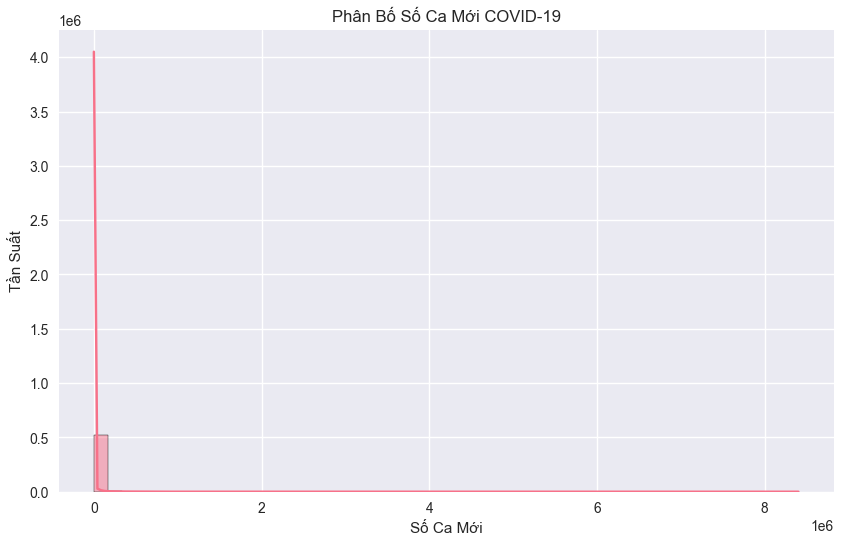

Skewness: 33.59 (Lệch phải nếu >0)
Kurtosis: 1631.96


In [5]:
# Histogram với KDE
plt.figure(figsize=(10, 6))
sns.histplot(new_cases, kde=True, bins=50)
plt.title('Phân Bố Số Ca Mới COVID-19')
plt.xlabel('Số Ca Mới')
plt.ylabel('Tần Suất')
plt.show()

# Tính skewness và kurtosis
skewness = stats.skew(new_cases)
kurtosis = stats.kurtosis(new_cases)
print(f'Skewness: {skewness:.2f} (Lệch phải nếu >0)')
print(f'Kurtosis: {kurtosis:.2f}')

### 4.2 Boxplot
Hiển thị Q1, Q2, Q3, outliers.

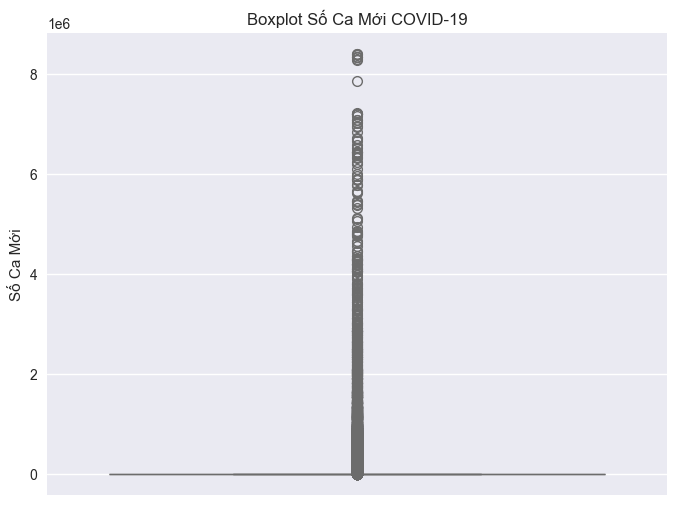

In [6]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=new_cases)
plt.title('Boxplot Số Ca Mới COVID-19')
plt.ylabel('Số Ca Mới')
plt.show()

## 5. Kết Luận

- Dữ liệu new_cases thường có phân bố lệch phải với nhiều giá trị 0 và vài đỉnh cao.
- Độ lệch chuẩn cao cho thấy sự biến động lớn.
- Sử dụng trung vị thay vì trung bình nếu có outliers.

